# Phase 3: Model Training and Churn Evaluation
## Customer Churn & LTV Prediction Engine

This notebook trains multiple machine learning classifiers to predict customer churn probability. It evaluates them using metrics suitable for imbalanced datasets (ROC-AUC, Precision-Recall, F1-Score) and serializes the champion model.

### Objectives:
1. Load preprocessed features and labels.
2. Train baseline models (Logistic Regression, Random Forest, XGBoost).
3. Fine-tune hyperparameters using GridSearchCV/RandomizedSearchCV.
4. Assess model quality using confusion matrices, ROC curves, and calibration curves.
5. Save the best model and parameters to the `models/` directory.

In [1]:
import pandas as pd
import joblib

# 1. Load the split datasets
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

# We use .values.ravel() to convert the y dataframes into 1D arrays, 
# which prevents Scikit-Learn from showing warnings during training.
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# 2. Load the saved preprocessor object
preprocessor = joblib.load('../models/preprocessor.joblib')

# 3. Transform the raw features into model-ready numeric features
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# 4. Verify shapes
print("Datasets loaded and transformed successfully!")
print(f"X_train_trans shape: {X_train_trans.shape}")
print(f"X_test_trans shape: {X_test_trans.shape}")


Datasets loaded and transformed successfully!
X_train_trans shape: (5634, 38)
X_test_trans shape: (1409, 38)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# 1. Initialize models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

# 2. Fit models on transformed training data
print("Training Logistic Regression...")
log_reg.fit(X_train_trans, y_train)

print("Training Random Forest...")
rf_clf.fit(X_train_trans, y_train)

# 3. Evaluate Logistic Regression
y_pred_lr = log_reg.predict(X_test_trans)
y_prob_lr = log_reg.predict_proba(X_test_trans)[:, 1]

print("\n=== LOGISTIC REGRESSION EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# 4. Evaluate Random Forest
y_pred_rf = rf_clf.predict(X_test_trans)
y_prob_rf = rf_clf.predict_proba(X_test_trans)[:, 1]

print("\n=== RANDOM FOREST EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Training Logistic Regression...
Training Random Forest...

=== LOGISTIC REGRESSION EVALUATION ===
Accuracy: 0.8098
ROC-AUC: 0.8476

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.87      1035
           1       0.68      0.55      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


=== RANDOM FOREST EVALUATION ===
Accuracy: 0.7850
ROC-AUC: 0.8209

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [3]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None] # 'balanced' automatically adjusts weights for class imbalance!
}

# 2. Initialize the Grid Search
# We optimize for 'roc_auc' since it balances true positives and false positives
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 3. Fit Grid Search
print("Running Grid Search (this may take a few seconds)...")
grid_search.fit(X_train_trans, y_train)

# 4. Get the best estimator
best_rf = grid_search.best_estimator_

# 5. Evaluate the best tuned model
y_pred_tuned = best_rf.predict(X_test_trans)
y_prob_tuned = best_rf.predict_proba(X_test_trans)[:, 1]

print("\n=== TUNED RANDOM FOREST EVALUATION ===")
print("Best Parameters:", grid_search.best_params_)
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


Running Grid Search (this may take a few seconds)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

=== TUNED RANDOM FOREST EVALUATION ===
Best Parameters: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 150}
Accuracy: 0.7601
ROC-AUC: 0.8438

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



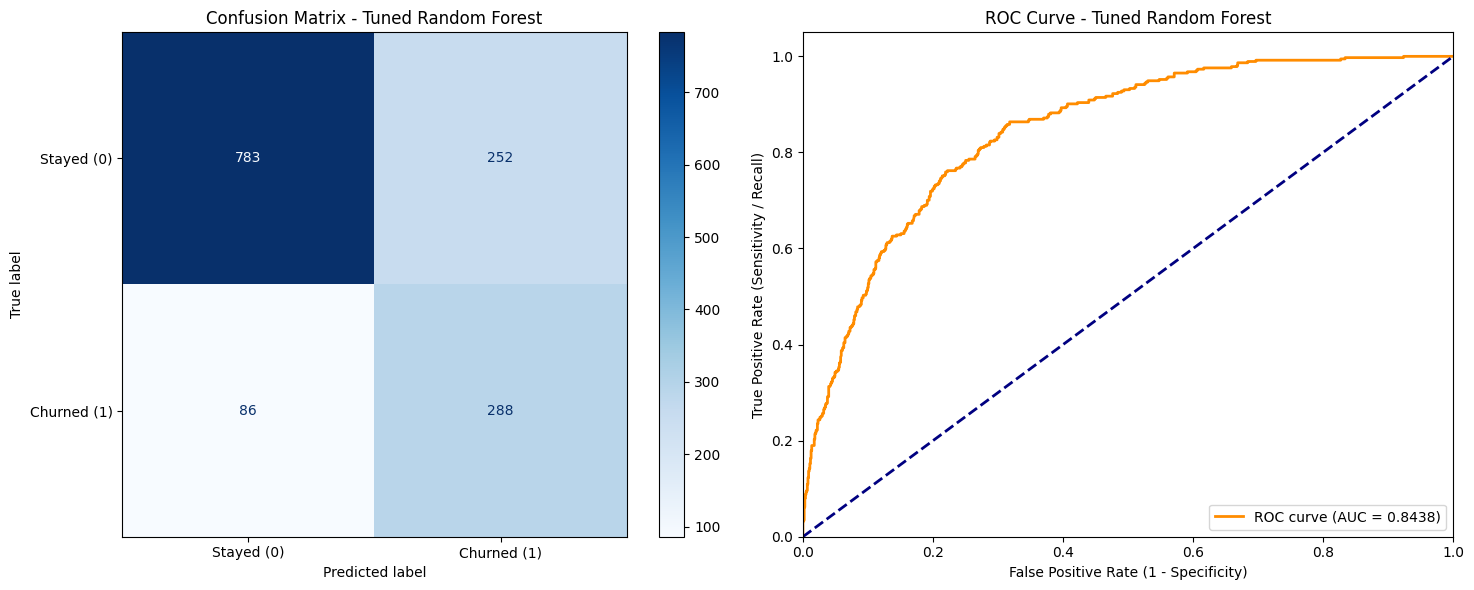

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Set up the plotting area
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Churned (1)'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Tuned Random Forest')
axes[0].grid(False) # Turn off grid lines for confusion matrix

# 2. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[1].set_title('ROC Curve - Tuned Random Forest')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


In [6]:
import os
import joblib

# Save the best model from our grid search to disk
model_output_path = '../models/churn_model.joblib'
joblib.dump(best_rf, model_output_path)

print("Champion model successfully saved!")
print(f"Model saved to: {os.path.abspath(model_output_path)}")


Champion model successfully saved!
Model saved to: c:\Users\Rudra Pratap Giri\OneDrive\Desktop\Internship Project1\customer-churn-ltv-engine\models\churn_model.joblib
